## Processamento de Linguagem Natural - assignment 1

## 03. Feature Representation 

- `resp_no_punct`
- `resp_with_punct`
- `comb_no_punct`
- `comb_with_punct`

comparar impacto de:

1. usar apenas a **response** vs **prompt + response**
2. **remover** ou **manter pontuação**

> Nota importante: para os datasets `*_with_punct`, os vetorizadores foram configurados para **preservar tokens de pontuação**.  
> Se usássemos o `CountVectorizer` / `TfidfVectorizer` por defeito, sinais como `!`, `?` ou sequências repetidas de pontuação podiam ser ignorados.


In this notebook, we extract and compare multiple text representations across the four preprocessed dataset variants. We consider sparse features (Bag-of-Words and TF-IDF), richer sparse representations with bigrams and dense sentence-level representations derived from Word2Vec.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import save_npz
import joblib

from wordcloud import WordCloud

# Word2Vec 
try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except Exception as e:
    GENSIM_AVAILABLE = False
    print("gensim não disponível:", e)


In [4]:
# caminhos base
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = PROJECT_ROOT / "data" / "features"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

# mapeamento dos 4 datasets
DATASETS = {
    "resp_no_punct": {
        "train_path": DATA_DIR / "resp_no_punct_train.csv",
        "test_path": DATA_DIR / "resp_no_punct_test.csv",
        "text_col": "resp_no_punct",
    },
    "resp_with_punct": {
        "train_path": DATA_DIR / "resp_with_punct_train.csv",
        "test_path": DATA_DIR / "resp_with_punct_test.csv",
        "text_col": "resp_with_punct",
    },
    "comb_no_punct": {
        "train_path": DATA_DIR / "comb_no_punct_train.csv",
        "test_path": DATA_DIR / "comb_no_punct_test.csv",
        "text_col": "comb_no_punct",
    },
    "comb_with_punct": {
        "train_path": DATA_DIR / "comb_with_punct_train.csv",
        "test_path": DATA_DIR / "comb_with_punct_test.csv",
        "text_col": "comb_with_punct",
    },
}

DATASETS


{'resp_no_punct': {'train_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-project1/data/processed/resp_no_punct_train.csv'),
  'test_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-project1/data/processed/resp_no_punct_test.csv'),
  'text_col': 'resp_no_punct'},
 'resp_with_punct': {'train_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-project1/data/processed/resp_with_punct_train.csv'),
  'test_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-project1/data/processed/resp_with_punct_test.csv'),
  'text_col': 'resp_with_punct'},
 'comb_no_punct': {'train_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-project1/data/processed/comb_no_punct_train.csv'),
  'test_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-project1/data/processed/comb_no_punct_test.csv'),
  'text_col': 'comb_no_punct'},
 'comb_with_punct': {'train_path': PosixPath('/Users/carolinapires/Documents/UP/25 26/NLP/NLP-p

In [5]:
def whitespace_tokenizer(text):
    """Divide o texto pelos espaços.

    Isto é importante porque o preprocessing já devolve o texto tokenizado/normalizado.
    Assim, preservamos também tokens de pontuação, por exemplo: ! ? ...
    """
    return str(text).split()


def build_vectorizers(max_features_bow=5000, max_features_tfidf=5000, max_features_bigram=7000):
    bow_vectorizer = CountVectorizer(
        tokenizer=whitespace_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        max_features=max_features_bow
    )

    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=whitespace_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        max_features=max_features_tfidf
    )

    tfidf_bigram = TfidfVectorizer(
        tokenizer=whitespace_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        max_features=max_features_bigram,
        ngram_range=(1, 2)
    )

    return bow_vectorizer, tfidf_vectorizer, tfidf_bigram


In [6]:
def load_variant(variant_name):
    cfg = DATASETS[variant_name]

    train_df = pd.read_csv(cfg["train_path"])
    test_df = pd.read_csv(cfg["test_path"])

    text_col = cfg["text_col"]

    X_train = train_df[text_col].fillna("").astype(str)
    y_train = train_df["is_safe"].astype(int)

    X_test = test_df[text_col].fillna("").astype(str)
    y_test = test_df["is_safe"].astype(int)

    return train_df, test_df, X_train, y_train, X_test, y_test, text_col


In [7]:
def extract_features_for_variant(variant_name, save_artifacts=True):
    train_df, test_df, X_train, y_train, X_test, y_test, text_col = load_variant(variant_name)

    bow_vectorizer, tfidf_vectorizer, tfidf_bigram = build_vectorizers()

    # BoW
    X_train_bow = bow_vectorizer.fit_transform(X_train)
    X_test_bow = bow_vectorizer.transform(X_test)

    # TF-IDF
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    # TF-IDF com bigrams
    X_train_bigram = tfidf_bigram.fit_transform(X_train)
    X_test_bigram = tfidf_bigram.transform(X_test)

    # Word2Vec
    X_train_tokens = [text.split() for text in X_train]
    X_test_tokens = [text.split() for text in X_test]

    w2v_model = None
    X_train_w2v, X_test_w2v = None, None

    if GENSIM_AVAILABLE:
        w2v_model = Word2Vec(
            sentences=X_train_tokens,
            vector_size=100,
            window=5,
            min_count=2,
            workers=4,
            epochs=10
        )

        def sentence_vector(tokens, model, vector_size=100):
            vecs = [model.wv[w] for w in tokens if w in model.wv]
            if vecs:
                return np.mean(vecs, axis=0)
            return np.zeros(vector_size)

        X_train_w2v = np.array([sentence_vector(t, w2v_model) for t in X_train_tokens])
        X_test_w2v = np.array([sentence_vector(t, w2v_model) for t in X_test_tokens])

    if save_artifacts:
        # Matrizes
        save_npz(FEATURE_DIR / f"{variant_name}_X_train_bow.npz", X_train_bow)
        save_npz(FEATURE_DIR / f"{variant_name}_X_test_bow.npz", X_test_bow)

        save_npz(FEATURE_DIR / f"{variant_name}_X_train_tfidf.npz", X_train_tfidf)
        save_npz(FEATURE_DIR / f"{variant_name}_X_test_tfidf.npz", X_test_tfidf)

        save_npz(FEATURE_DIR / f"{variant_name}_X_train_bigram.npz", X_train_bigram)
        save_npz(FEATURE_DIR / f"{variant_name}_X_test_bigram.npz", X_test_bigram)

        # labels
        y_train.to_csv(FEATURE_DIR / f"{variant_name}_y_train.csv", index=False)
        y_test.to_csv(FEATURE_DIR / f"{variant_name}_y_test.csv", index=False)

        # vectorizers
        joblib.dump(bow_vectorizer, FEATURE_DIR / f"{variant_name}_bow_vectorizer.joblib")
        joblib.dump(tfidf_vectorizer, FEATURE_DIR / f"{variant_name}_tfidf_vectorizer.joblib")
        joblib.dump(tfidf_bigram, FEATURE_DIR / f"{variant_name}_tfidf_bigram_vectorizer.joblib")

        # Word2Vec
        if GENSIM_AVAILABLE and w2v_model is not None:
            np.save(FEATURE_DIR / f"{variant_name}_X_train_w2v.npy", X_train_w2v)
            np.save(FEATURE_DIR / f"{variant_name}_X_test_w2v.npy", X_test_w2v)
            w2v_model.save(str(FEATURE_DIR / f"{variant_name}_w2v.model"))

    return {
        "variant": variant_name,
        "text_col": text_col,
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "bow_vectorizer": bow_vectorizer,
        "tfidf_vectorizer": tfidf_vectorizer,
        "tfidf_bigram": tfidf_bigram,
        "X_train_bow": X_train_bow,
        "X_test_bow": X_test_bow,
        "X_train_tfidf": X_train_tfidf,
        "X_test_tfidf": X_test_tfidf,
        "X_train_bigram": X_train_bigram,
        "X_test_bigram": X_test_bigram,
        "X_train_w2v": X_train_w2v,
        "X_test_w2v": X_test_w2v,
    }


In [8]:
# correr o pipeline para os 4 datasets
results = {}
summary_rows = []

for variant_name in DATASETS.keys():
    print(f"\n=== A processar: {variant_name} ===")
    res = extract_features_for_variant(variant_name, save_artifacts=True)
    results[variant_name] = res

    summary_rows.append({
        "dataset": variant_name,
        "n_train": res["X_train"].shape[0],
        "n_test": res["X_test"].shape[0],
        "bow_features": res["X_train_bow"].shape[1],
        "tfidf_features": res["X_train_tfidf"].shape[1],
        "bigram_features": res["X_train_bigram"].shape[1],
        "w2v_dim": None if res["X_train_w2v"] is None else res["X_train_w2v"].shape[1],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df



=== A processar: resp_no_punct ===

=== A processar: resp_with_punct ===

=== A processar: comb_no_punct ===

=== A processar: comb_with_punct ===


,dataset,n_train,n_test,bow_features,tfidf_features,bigram_features,w2v_dim
0,resp_no_punct,20297,1003,5000,5000,7000,100
1,resp_with_punct,20297,1003,5000,5000,7000,100
2,comb_no_punct,20297,1003,5000,5000,7000,100
3,comb_with_punct,20297,1003,5000,5000,7000,100


### Escolher um dataset 

já se extraiu features para os 4 datasets.  
Nas células seguintes escolher **um** deles para inspecionar melhor
(vocabulário, top palavras, word cloud, etc.).


In [9]:
ACTIVE_VARIANT = "resp_no_punct"   # alterar aqui 

# resp_no_punct
# resp_with_punct
# comb_no_punct
# comb_with_punct

res = results[ACTIVE_VARIANT]

train_df = res["train_df"]
test_df = res["test_df"]
X_train = res["X_train"]
y_train = res["y_train"]
X_test = res["X_test"]
y_test = res["y_test"]

bow_vectorizer = res["bow_vectorizer"]
tfidf_vectorizer = res["tfidf_vectorizer"]
tfidf_bigram = res["tfidf_bigram"]

X_train_bow = res["X_train_bow"]
X_test_bow = res["X_test_bow"]
X_train_tfidf = res["X_train_tfidf"]
X_test_tfidf = res["X_test_tfidf"]
X_train_bigram = res["X_train_bigram"]
X_test_bigram = res["X_test_bigram"]
X_train_w2v = res["X_train_w2v"]
X_test_w2v = res["X_test_w2v"]

print("Dataset ativo:", ACTIVE_VARIANT)
print("Coluna usada:", res["text_col"])
print("BoW shape:", X_train_bow.shape)
print("TF-IDF shape:", X_train_tfidf.shape)
print("TF-IDF bigram shape:", X_train_bigram.shape)
if X_train_w2v is not None:
    print("Word2Vec shape:", X_train_w2v.shape)


Dataset ativo: resp_no_punct
Coluna usada: resp_no_punct
BoW shape: (20297, 5000)
TF-IDF shape: (20297, 5000)
TF-IDF bigram shape: (20297, 7000)
Word2Vec shape: (20297, 100)


In [10]:
# vocabulário aprendido pelo BoW
feature_names_bow = bow_vectorizer.get_feature_names_out()

print("Primeiras 100 features:")
print(feature_names_bow[:100])


Primeiras 100 features:
['0' '1' '10' '100' '11' '12' '123' '13' '14' '15' '16' '17' '18' '19' '2'
 '20' '200' '2000' '2008' '2009' '2010' '2013' '2015' '2016' '2017' '2018'
 '2019' '2020' '21' '23' '24' '25' '250' '28' '29' '3' '30' '35' '3d' '4'
 '40' '45' '5' '50' '500' '6' '60' '7' '8' '800' '9' 'abajo' 'abandonar'
 'abast' 'abiertamente' 'abierto' 'abocar' 'abogado' 'abordar' 'aborto'
 'abrir' 'absolut' 'absoluto' 'abusar' 'abuso' 'abús' 'acabar' 'acabat'
 'acadèmic' 'académico' 'acarrear' 'acceder' 'accedir' 'acceptable'
 'acceptar' 'acceso' 'accident' 'accidental' 'accidente' 'accions' 'acció'
 'acción' 'accés' 'aceite' 'aceptable' 'aceptar' 'acercar' 'acero'
 'aclaparador' 'aclarar' 'aclarir' 'aconseguir' 'aconseguit' 'acord'
 'acoso' 'acostar' 'acre' 'acte' 'actitud' 'actiu']


In [11]:
# palavras/tokens mais frequentes no conjunto de treino (BoW)
word_counts = np.asarray(X_train_bow.sum(axis=0)).flatten()

top_indices = word_counts.argsort()[-20:][::-1]
top_words = feature_names_bow[top_indices]
top_counts = word_counts[top_indices]

top_bow_df = pd.DataFrame({
    "token": top_words,
    "count": top_counts
})

top_bow_df


,token,count
0,poder,32497
1,él,10901
2,de,9911
3,persona,7952
4,ser,7942
5,el,7791
6,si,7692
7,1,5516
8,hacer,5426
9,cosa,5235


In [12]:
# features do TF-IDF
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Primeiras 100 features TF-IDF:")
print(feature_names_tfidf[:100])


Primeiras 100 features TF-IDF:
['0' '1' '10' '100' '11' '12' '123' '13' '14' '15' '16' '17' '18' '19' '2'
 '20' '200' '2000' '2008' '2009' '2010' '2013' '2015' '2016' '2017' '2018'
 '2019' '2020' '21' '23' '24' '25' '250' '28' '29' '3' '30' '35' '3d' '4'
 '40' '45' '5' '50' '500' '6' '60' '7' '8' '800' '9' 'abajo' 'abandonar'
 'abast' 'abiertamente' 'abierto' 'abocar' 'abogado' 'abordar' 'aborto'
 'abrir' 'absolut' 'absoluto' 'abusar' 'abuso' 'abús' 'acabar' 'acabat'
 'acadèmic' 'académico' 'acarrear' 'acceder' 'accedir' 'acceptable'
 'acceptar' 'acceso' 'accident' 'accidental' 'accidente' 'accions' 'acció'
 'acción' 'accés' 'aceite' 'aceptable' 'aceptar' 'acercar' 'acero'
 'aclaparador' 'aclarar' 'aclarir' 'aconseguir' 'aconseguit' 'acord'
 'acoso' 'acostar' 'acre' 'acte' 'actitud' 'actiu']


In [13]:
# exemplos de bigrams
features_bigram = tfidf_bigram.get_feature_names_out()

bigram_examples = [f for f in features_bigram if " " in f][:30]
bigram_examples


['1 agradar',
 '1 cortar',
 '1 cucharaditar',
 '1 cucharado',
 '1 culleradeta',
 '1 gustar',
 '1 identificar',
 '1 investigació',
 '1 investigar',
 '1 litro',
 '1 quitar',
 '1 resposta',
 '1 respuesta',
 '1 tassa',
 '1 taza',
 '10 any',
 '10 año',
 '16 any',
 '16 año',
 '18 any',
 '18 año',
 '2 identificar',
 '2 recopilar',
 '2 utilitzar',
 '20 any',
 '24 hora',
 '250 gramo',
 '3 usar',
 '3 utilitzar',
 '4 usar']

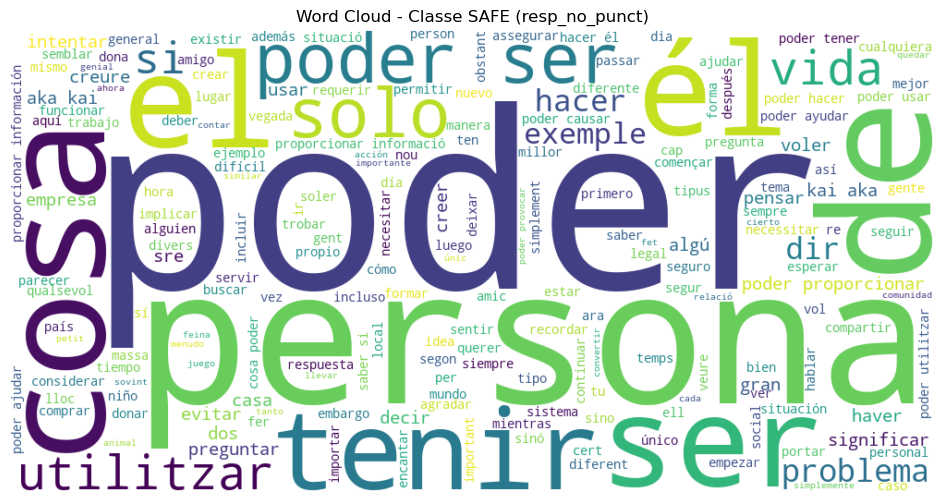

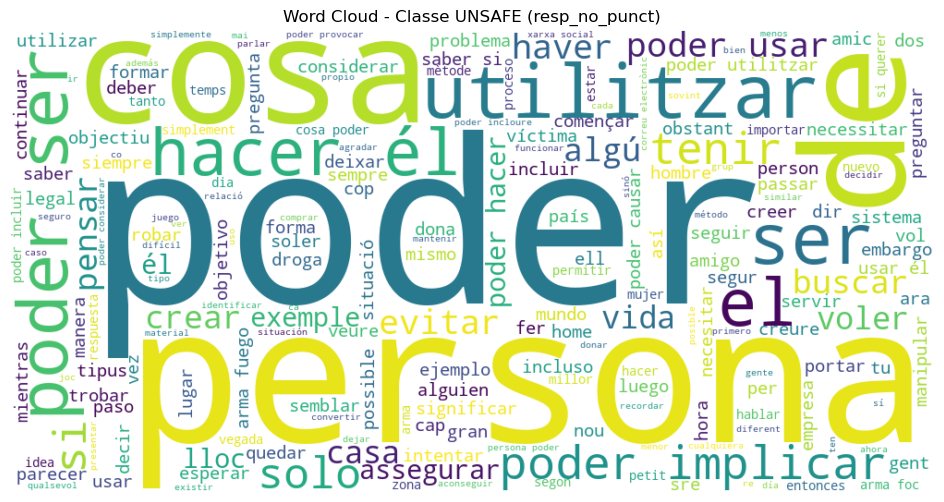

In [14]:
# word clouds por classe
safe_text = " ".join(X_train[y_train == 1].fillna(""))
unsafe_text = " ".join(X_train[y_train == 0].fillna(""))

wc_safe = WordCloud(width=1000, height=500, background_color="white").generate(safe_text)
wc_unsafe = WordCloud(width=1000, height=500, background_color="white").generate(unsafe_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc_safe, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud - Classe SAFE ({ACTIVE_VARIANT})")
plt.show()

plt.figure(figsize=(14, 6))
plt.imshow(wc_unsafe, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud - Classe UNSAFE ({ACTIVE_VARIANT})")
plt.show()


In [15]:
# palavras mais associadas a cada classe segundo o TF-IDF
mask_safe = (y_train == 1).to_numpy()
mask_unsafe = (y_train == 0).to_numpy()

X_safe = X_train_tfidf[mask_safe]
X_unsafe = X_train_tfidf[mask_unsafe]

mean_safe = X_safe.mean(axis=0).A1
mean_unsafe = X_unsafe.mean(axis=0).A1

feature_names = tfidf_vectorizer.get_feature_names_out()

diff = mean_unsafe - mean_safe

top_unsafe_idx = np.argsort(diff)[-15:][::-1]
top_safe_idx = np.argsort(diff)[:15]

print("Top tokens UNSAFE:")
print(feature_names[top_unsafe_idx])

print("\nTop tokens SAFE:")
print(feature_names[top_safe_idx])


Top tokens UNSAFE:
['él' 'arma' 'el' 'utilitzar' 'ser' 'matar' 'robar' '1' '2' 'evitar' 'de'
 'usar' '3' 'si' 'voler']

Top tokens SAFE:
['proporcionar' 'informació' 'información' 'hablar' 'parlar' 'quizás'
 'discutir' 'cosa' 'perjudicial' 'entender' 'tema' 'considerado'
 'considerat' 'entendre' 'importante']


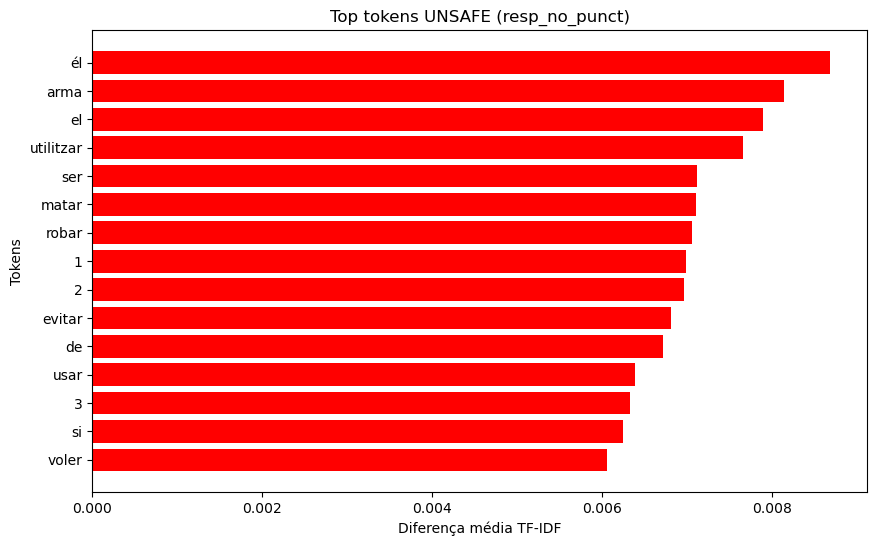

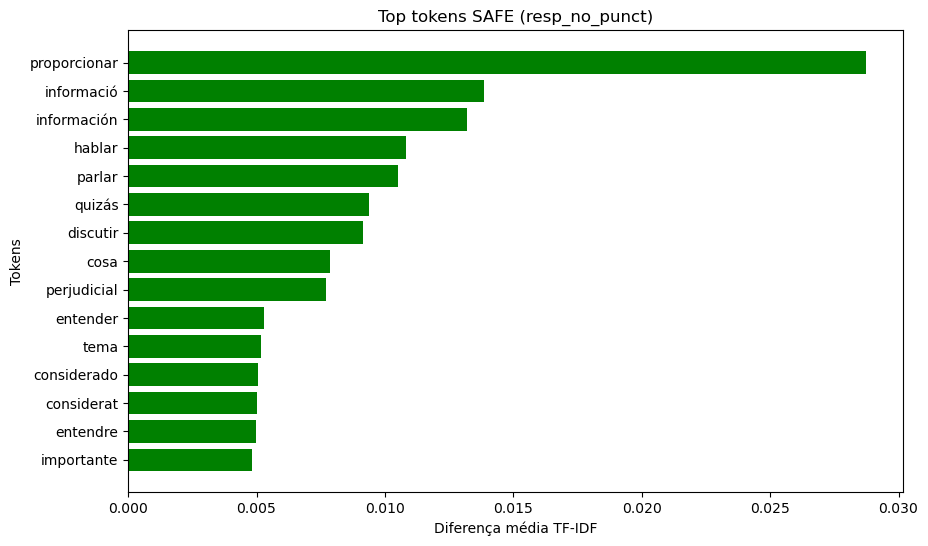

In [16]:
def plot_top_words(words, scores, title, color):
    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], scores[::-1], color=color)
    plt.title(title)
    plt.xlabel("Diferença média TF-IDF")
    plt.ylabel("Tokens")
    plt.show()


top_unsafe_words = feature_names[top_unsafe_idx]
top_safe_words = feature_names[top_safe_idx]

top_unsafe_scores = diff[top_unsafe_idx]
top_safe_scores = np.abs(diff[top_safe_idx])

plot_top_words(top_unsafe_words, top_unsafe_scores, f"Top tokens UNSAFE ({ACTIVE_VARIANT})", "red")
plot_top_words(top_safe_words, top_safe_scores, f"Top tokens SAFE ({ACTIVE_VARIANT})", "green")


### Notas finais

- Os ficheiros de features ficam guardados em `../data/features/`
- Versão das features para **cada um dos 4 datasets**
- Para comparar cenários:
  - `resp_no_punct`
  - `resp_with_punct`
  - `comb_no_punct`
  - `comb_with_punct`

Assim dá para medir o impacto de:
- pontuação
- uso de prompt + response vs só response
